# Predictive Cricket Batting Analysis
Modernized implementation using advance feature engineering and ensemble models.

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import lightgbm as lgb
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor
import shap
import joblib
import yaml
import warnings

warnings.filterwarnings('ignore')
sns.set(style="whitegrid")

# Custom modules
from src.predictive.data_loader import load_batters_data, validate_schema, load_config
from src.predictive.preprocessor import PredictivePreprocessor
from src.predictive.feature_engineering import engineer_all_features
from src.predictive.model import evaluate_model, train_baseline_models, train_xgboost_model, compare_models, explain_model_with_shap

config = load_config()
print("Setup complete.")

Setup complete.


In [2]:
# Load data
df_raw = load_batters_data()
validate_schema(df_raw)

# Preprocess
preprocessor = PredictivePreprocessor(config)
df_clean = preprocessor.clean_data(df_raw)
print(f"Data cleaned. Initial shape: {df_clean.shape}")

Loaded 50630 rows from data\batters.csv
Data cleaned. Initial shape: (50630, 11)


In [3]:
# Engineer Features
df_features = engineer_all_features(df_clean)

# Final Encoding and Scaling
df_final = preprocessor.fit_transform(df_features)
print(f"Feature engineering complete. Final shape: {df_final.shape}")
df_final.head()

Feature engineering complete. Final shape: (50630, 19)


,Player,Runs,Not_Out,BF,Fours,Sixes,SR,Inns,Opposition,Ground,Start_Date,Year,Month,Career_Age_Days,Runs_Avg_L5,SR_Avg_L5,Runs_Avg_L10,SR_Avg_L10,Boundary_Pct
41494,-1.742541,0,-0.42484,-0.818227,-0.546575,-0.402165,-0.978551,0.999813,1.373595,1.300714,2023-06-24,-0.568454,-0.428995,-1.066950,-0.939497,-1.368784,-1.000832,-1.459478,-0.789762
41531,-1.742541,0,-0.42484,-0.818227,-0.546575,-0.402165,-0.978551,-2.831158,0.858993,1.300714,2023-06-25,-0.568454,-0.428995,-1.064556,-0.939497,-1.368784,-1.000832,-1.459478,-0.789762
28820,-1.742541,2,-0.42484,-0.315354,-0.546575,-0.402165,-0.519110,0.999813,0.119253,-0.889248,2024-08-25,0.268490,0.204195,-0.042197,-0.939497,-1.368784,-1.000832,-1.459478,-0.789762
21440,-1.741483,6,-0.42484,-0.063918,0.038888,-0.402165,-0.059669,0.999813,0.633855,1.746131,2022-06-28,-1.405397,-0.428995,-1.066950,-0.939497,-1.368784,-1.000832,-1.459478,1.229461
12366,-1.741483,16,-0.42484,0.858016,0.624351,-0.402165,0.124218,-0.915673,1.084132,-0.295360,2022-06-29,-1.405397,-0.428995,-1.064556,-0.422749,-0.016796,-0.453137,-0.019520,0.724655


## Exploratory Data Analysis

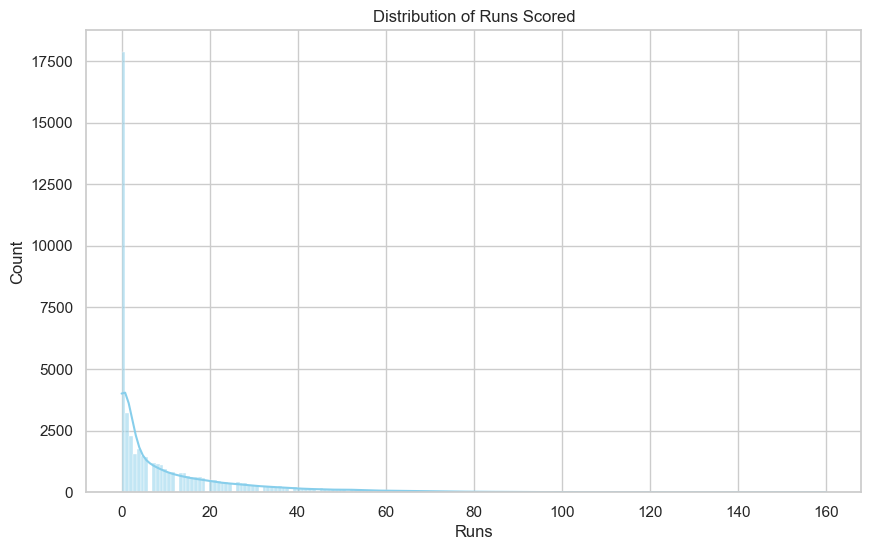

In [4]:
# Distribution of Runs
plt.figure(figsize=(10, 6))
sns.histplot(df_clean['Runs'], kde=True, color='skyblue')
plt.title('Distribution of Runs Scored')
plt.savefig('reports/figures/runs_distribution.png')
plt.show()

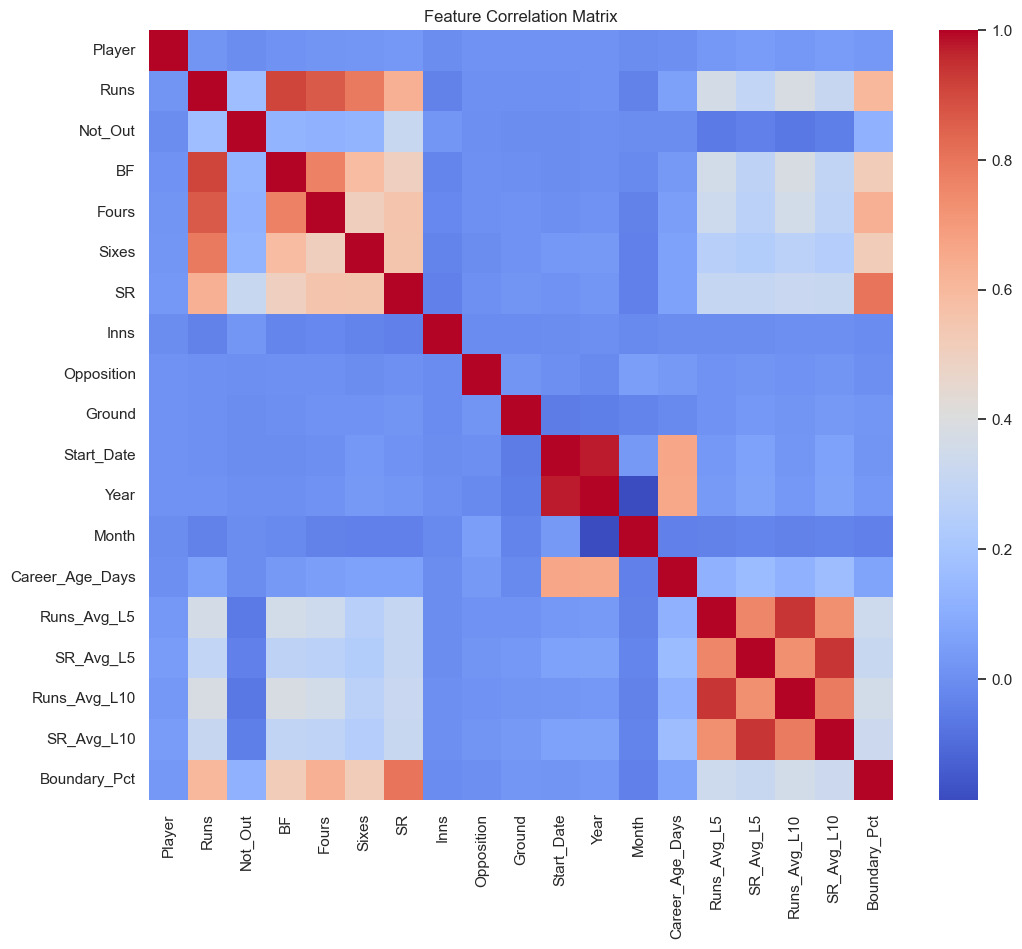

In [5]:
# Correlation Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(df_final.corr(), annot=False, cmap='coolwarm')
plt.title('Feature Correlation Matrix')
plt.savefig('reports/figures/correlation_heatmap.png')
plt.show()

## Modeling & Evaluation

In [6]:
# Time-based split
df_final = df_final.sort_values('Start_Date')
X = df_final.drop(columns=['Runs', 'Start_Date'])
y = df_final['Runs']

# Split: 70% Train, 15% Val, 15% Test
n = len(df_final)
train_idx = int(n * 0.7)
val_idx = int(n * 0.85)

X_train, y_train = X.iloc[:train_idx], y.iloc[:train_idx]
X_val, y_val = X.iloc[train_idx:val_idx], y.iloc[train_idx:val_idx]
X_test, y_test = X.iloc[val_idx:], y.iloc[val_idx:]

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

Train: (35441, 17), Val: (7594, 17), Test: (7595, 17)


In [ ]:
results = {}

In [ ]:


# Baselines
baseline_models = train_baseline_models(X_train, y_train)
for name, model in baseline_models.items():
    results[name] = evaluate_model(model, X_val, y_val, name)

[LR] R2: 0.9848, MAE: 1.5617, RMSE: 2.1891
[RF] R2: 0.9992, MAE: 0.0740, RMSE: 0.4979


In [ ]:
# XGBoost
xgb_model = train_xgboost_model(X_train, y_train, X_val, y_val)
results['XGBoost'] = evaluate_model(xgb_model, X_val, y_val, "XGBoost")

[0]	validation_0-rmse:16.88345
[1]	validation_0-rmse:16.06750
[2]	validation_0-rmse:15.29165
[3]	validation_0-rmse:14.55735
[4]	validation_0-rmse:13.85560
[5]	validation_0-rmse:13.19159
[6]	validation_0-rmse:12.55448
[7]	validation_0-rmse:11.94993
[8]	validation_0-rmse:11.37721
[9]	validation_0-rmse:10.82973
[10]	validation_0-rmse:10.31030
[11]	validation_0-rmse:9.81383
[12]	validation_0-rmse:9.34172
[13]	validation_0-rmse:8.89658
[14]	validation_0-rmse:8.47076
[15]	validation_0-rmse:8.06706
[16]	validation_0-rmse:7.68414
[17]	validation_0-rmse:7.31797
[18]	validation_0-rmse:6.97279
[19]	validation_0-rmse:6.64317
[20]	validation_0-rmse:6.32932
[21]	validation_0-rmse:6.03037
[22]	validation_0-rmse:5.74476
[23]	validation_0-rmse:5.47348
[24]	validation_0-rmse:5.21490
[25]	validation_0-rmse:4.96831
[26]	validation_0-rmse:4.73321
[27]	validation_0-rmse:4.51385
[28]	validation_0-rmse:4.30485
[29]	validation_0-rmse:4.10891
[30]	validation_0-rmse:3.91526
[31]	validation_0-rmse:3.73264
[32]	va

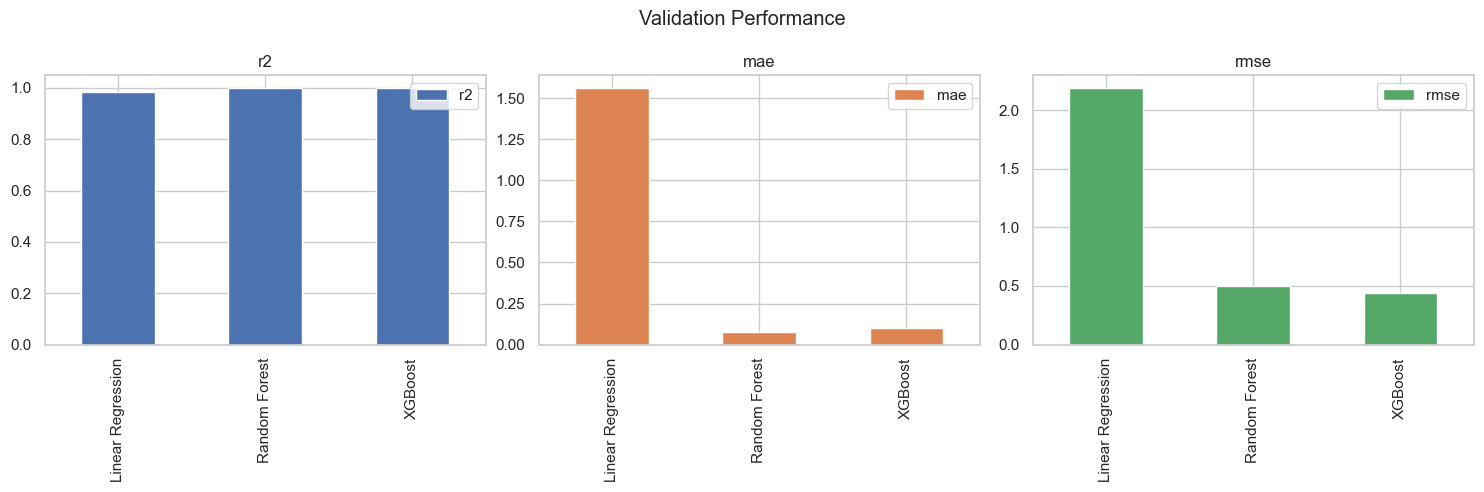

In [ ]:
# Model Comparison
compare_models(results, save_path='reports/figures/model_comparison.png')

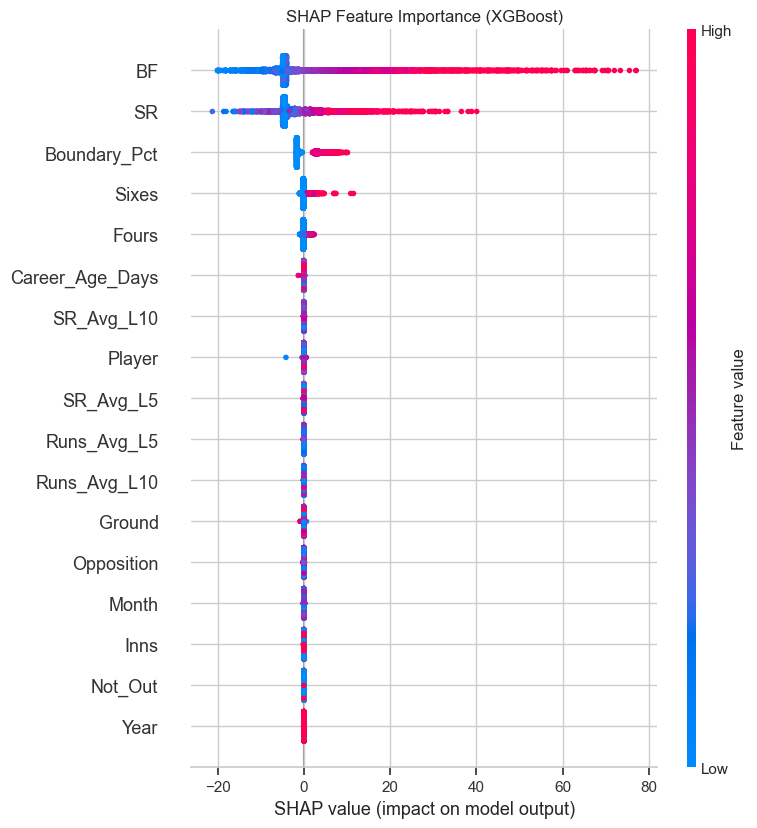

In [ ]:
# SHAP Interpretability
explainer, shap_values = explain_model_with_shap(xgb_model, X_val, save_path='reports/figures')
shap.summary_plot(shap_values, X_val, show=False)
plt.title("SHAP Feature Importance (XGBoost)")
plt.savefig('reports/figures/shap_summary.png')
plt.show()

In [16]:
# Save the best model
joblib.dump(xgb_model, 'models/best_xgb_model.joblib')
print("Model saved to models/best_xgb_model.joblib")

Model saved to models/best_xgb_model.joblib
